In [1]:
import os
import glob
import cv2
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import albumentations as A
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf
import random
import json

# Reproducibility seeds
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [2]:
file_path ='../../dataset/dataset_blood_group'

# List all classes in the dataset
name_class = os.listdir(file_path)
print(name_class)

['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']


In [3]:
# Get file paths for all images in the dataset
filepaths = list(glob.glob(file_path + '/**/*.*'))

# Example of printing a subset of file paths
# print(filepaths[-6:-1])

# Extract labels from file paths
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))
print(labels)

['A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+

                                            Filepath Label
0  ../../dataset/dataset_blood_group\AB+\cluster_...   AB+
1  ../../dataset/dataset_blood_group\B-\cluster_3...    B-
2  ../../dataset/dataset_blood_group\A+\cluster_0...    A+
3  ../../dataset/dataset_blood_group\AB+\cluster_...   AB+
4  ../../dataset/dataset_blood_group\O+\cluster_6...    O+


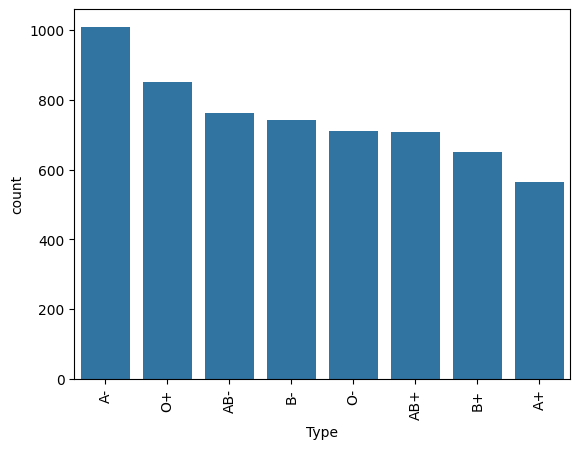

Classes: ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']
Counts per class:
 Label
A+      565
A-     1009
AB+     708
AB-     761
B+      652
B-      741
O+      852
O-      712
Name: count, dtype: int64


In [4]:
# Create a DataFrame with file paths and labels
filepath = pd.Series(filepaths, name='Filepath').astype(str)
Labels = pd.Series(labels, name='Label')
data = pd.concat([filepath, Labels], axis=1)
data = data.sample(frac=1).reset_index(drop=True)
print(data.head(5))

# Visualize class distribution
counts = data.Label.value_counts()
sns.barplot(x=counts.index, y=counts)
plt.xlabel('Type')
plt.xticks(rotation=90)
plt.show()

# Global classes and counts (used for consistent mapping)
classes = sorted(data.Label.unique())
class_counts = data.Label.value_counts().reindex(classes)
print('Classes:', classes)
print('Counts per class:\n', class_counts)

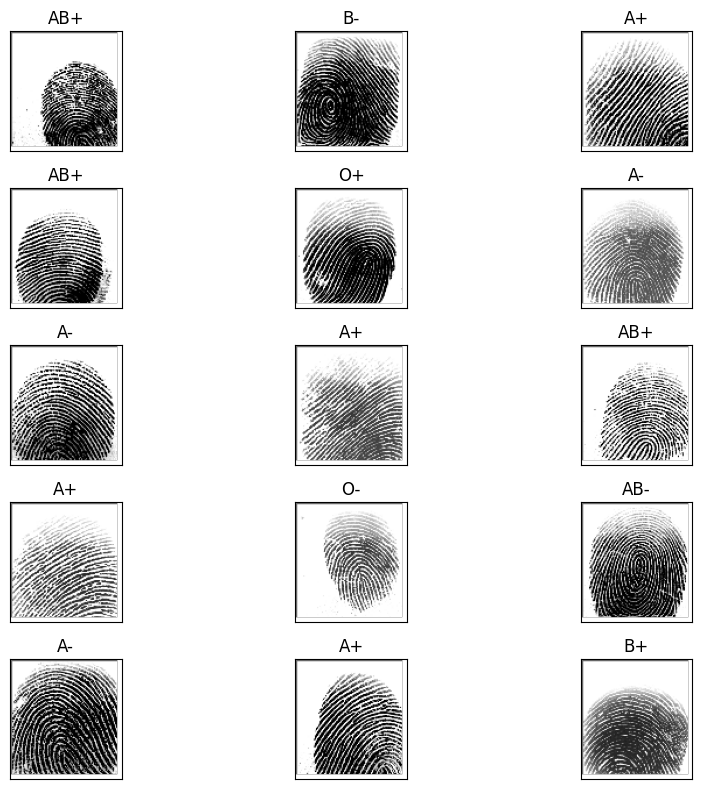

In [5]:
# Split data into training and testing sets
train, test = train_test_split(data, test_size=0.20, random_state=42)

# Visualize some images from the dataset
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(10, 8), subplot_kw={'xticks': [], 'yticks': []})
for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(data.Filepath[i]))
    ax.set_title(data.Label[i])
plt.tight_layout()
plt.show()

In [6]:
# Albumentations Transform (Training only)
train_transform = A.Compose([
    A.Rotate(limit=15, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(0.1, 0.1, p=0.3),
    A.HorizontalFlip(p=0.5)
])


class AlbumentationsDataGenerator(Sequence):

    def __init__(self, dataframe, batch_size, target_size, transform=None, shuffle=True, classes=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.target_size = target_size
        self.transform = transform
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.dataframe))
        # use provided classes mapping if available to keep consistency
        if classes is not None:
            self.classes = classes
        else:
            self.classes = sorted(self.dataframe['Label'].unique())
        self.class_to_index = {c:i for i,c in enumerate(self.classes)}
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.dataframe) / self.batch_size)

    def __getitem__(self, index):
        batch_indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]

        images = []
        labels = []

        for i in batch_indexes:
            img_path = self.dataframe.loc[i, 'Filepath']
            label = self.dataframe.loc[i, 'Label']

            image = cv2.imread(img_path)
            if image is None:
                # skip corrupted image
                continue
            image = cv2.resize(image, self.target_size)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            if self.transform:
                augmented = self.transform(image=image)
                image = augmented['image']

            # ensure float32 and apply VGG16 preprocessing
            image = image.astype('float32')
            image = preprocess_input(image)

            images.append(image)
            labels.append(self.class_to_index[label])

        return np.array(images), to_categorical(labels, num_classes=len(self.classes))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)


# Create Generators (224x224 for VGG16) - use consistent classes
train_gen = AlbumentationsDataGenerator(train, 32, (224,224), train_transform, classes=classes)
test_gen = AlbumentationsDataGenerator(test, 32, (224,224), None, shuffle=False, classes=classes)

c:\Users\ASUS\anaconda3\envs\BD\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [7]:
from tensorflow.keras.applications import VGG16

# Define the base pre-trained model (no top, imagenet weights)
vgg16_base = VGG16(
    input_shape=(224, 224, 3),   # Correct input size
    include_top=False,
    weights='imagenet',
    pooling=None
)

# Freeze convolutional base for initial training
vgg16_base.trainable = False

# Build a smaller classifier head (GlobalAveragePooling -> Dense -> BN -> Dropout -> Dense)
x = GlobalAveragePooling2D()(vgg16_base.output)
x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

# Final classification layer (num classes)
num_classes = len(classes)
outputs = Dense(num_classes, activation='softmax')(x)

# Create final model
vgg16_model = Model(inputs=vgg16_base.input, outputs=outputs)

# Compile (initial training, higher LR)
vgg16_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
rlp = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
chk = ModelCheckpoint('../../models/vgg16_best.keras', monitor='val_loss', save_best_only=True)

# Compute class weights to handle imbalance
class_weights_values = compute_class_weight('balanced', classes=np.array(classes), y=data['Label'])
class_weights = {i: w for i, w in enumerate(class_weights_values)}
print('Class weights:', class_weights)

# Initial training (base frozen)
history = vgg16_model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=30,
    class_weight=class_weights,
    callbacks=[es, rlp, chk]
)

# Fine-tuning: unfreeze last 8 layers of the base model
for layer in vgg16_base.layers[:-8]:
    layer.trainable = False
for layer in vgg16_base.layers[-8:]:
    layer.trainable = True

# Recompile with lower LR for fine-tuning
vgg16_model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Fine-tune for a few more epochs
history_fine = vgg16_model.fit( 
    train_gen,
    validation_data=test_gen,
    epochs=10,
    class_weight=class_weights,
    callbacks=[es, rlp, chk]
)

Class weights: {0: np.float64(1.3274336283185841), 1: np.float64(0.7433102081268583), 2: np.float64(1.0593220338983051), 3: np.float64(0.985545335085414), 4: np.float64(1.1503067484662577), 5: np.float64(1.0121457489878543), 6: np.float64(0.8802816901408451), 7: np.float64(1.053370786516854)}


c:\Users\ASUS\anaconda3\envs\BD\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 812s 5s/step - accuracy: 0.1783 - loss: 2.9102 - val_accuracy: 0.3050 - val_loss: 1.7614 - learning_rate: 1.0000e-04
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 383s 3s/step - accuracy: 0.2492 - loss: 2.4501 - val_accuracy: 0.3658 - val_loss: 1.6035 - learning_rate: 1.0000e-04
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 418s 3s/step - accuracy: 0.2994 - loss: 2.2384 - val_accuracy: 0.3725 - val_loss: 1.5544 - learning_rate: 1.0000e-04
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 401s 3s/step - accuracy: 0.3088 - loss: 2.1289 - val_accuracy: 0.3975 - val_loss: 1.4934 - learning_rate: 1.0000e-04
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 409s 3s/step - accuracy: 0.3300 - loss: 2.0176 - val_accuracy: 0.4100 - val_loss: 1.4558 - learning_rate: 1.0000e-04
Epoch 6/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 403s 3s/step - accuracy: 0.3606 - loss: 1.9143 - val_accuracy: 0.4225 - val_loss: 1.4066 - learning_rate: 1.0000e-04
Epoch 7/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 402s 3s/step - acc

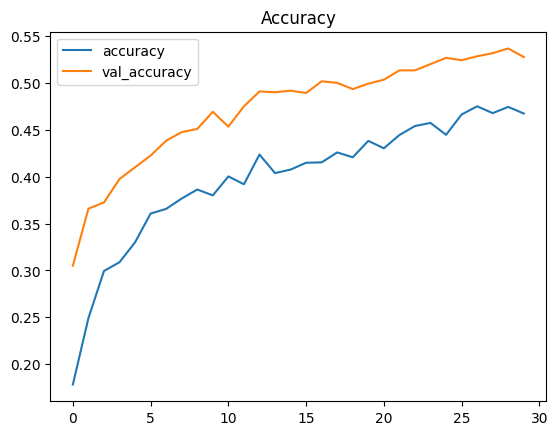

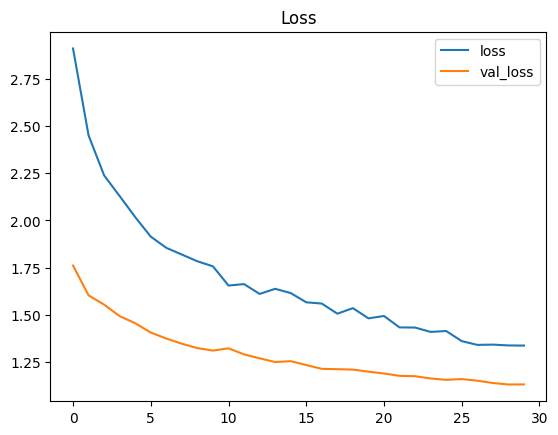

Test Loss: 0.37301
Test Accuracy: 87.67%
38/38 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step
              precision    recall  f1-score   support

          A+       0.88      0.94      0.91       120
          A-       0.90      0.88      0.89       218
         AB+       0.89      0.78      0.83       134
         AB-       0.88      0.91      0.90       152
          B+       0.93      0.81      0.87       123
          B-       0.88      0.93      0.91       148
          O+       0.88      0.87      0.87       178
          O-       0.78      0.88      0.83       127

    accuracy                           0.88      1200
   macro avg       0.88      0.88      0.88      1200
weighted avg       0.88      0.88      0.88      1200



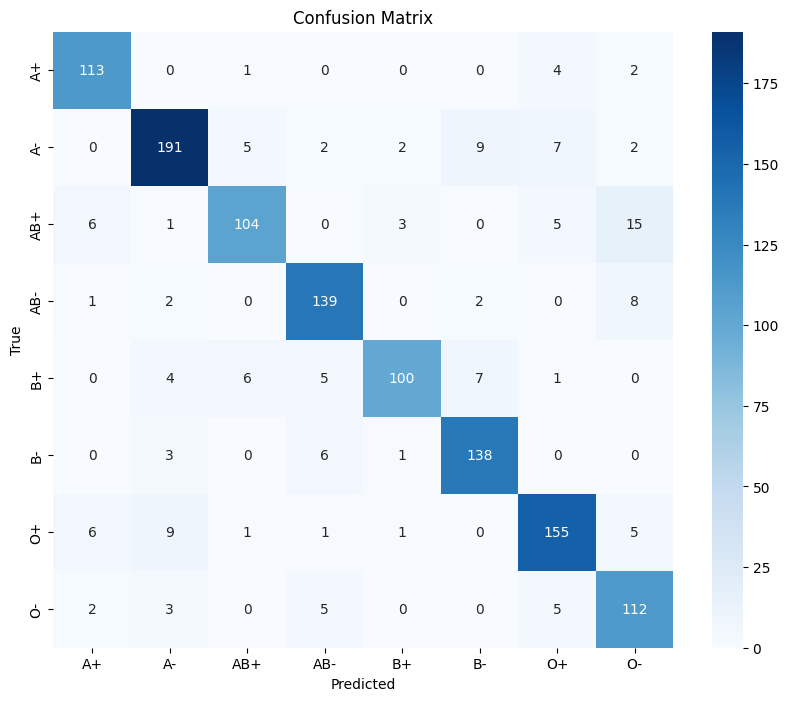

In [8]:
# Plot training history: accuracy
pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()
plt.title("Accuracy")
plt.show()

# Plot training history: loss
pd.DataFrame(history.history)[['loss', 'val_loss']].plot()
plt.title("Loss")
plt.show()

# Evaluate the model on test data
results = vgg16_model.evaluate(test_gen, verbose=0)
print(f"Test Loss: {results[0]:.5f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")

# Predict labels for test data (numeric indices)
pred_probs = vgg16_model.predict(test_gen)
pred_idx = np.argmax(pred_probs, axis=1)

# True labels as indices using the same mapping
class_to_index = {c:i for i,c in enumerate(classes)}
y_test_idx = test.Label.map(class_to_index).values

# Classification report with target names
print(classification_report(y_test_idx, pred_idx, target_names=classes))

# Confusion matrix
cm = confusion_matrix(y_test_idx, pred_idx)
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Save final model and class mapping
vgg16_model.save("../../models/vgg16_Model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
Prediction: O-
Confidence: 55.528408


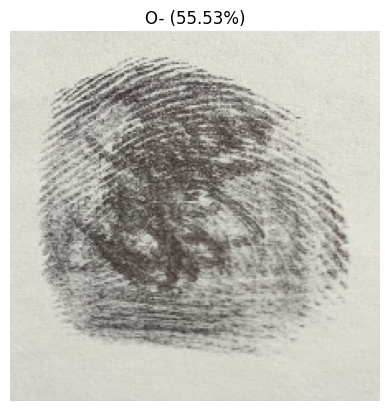

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load saved VGG16 model
model = load_model('../../models/vgg16_Model.keras')

# Load label mapping saved during training
with open('../../models/vgg16_classes.json', 'r') as f:
    classes_loaded = json.load(f)
labels_map = {i: c for i, c in enumerate(classes_loaded)}

# Image path
img_path = r"C:\Users\ASUS\Desktop\golu.jpg"

# Load image (VGG16 size)
img = image.load_img(img_path, target_size=(224, 224))

x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

# IMPORTANT: VGG16 preprocessing
x = preprocess_input(x)

# Prediction
result = model.predict(x)
predicted_class = np.argmax(result)

predicted_label = labels_map[predicted_class]
confidence = result[0][predicted_class] * 100

print("Prediction:", predicted_label)
print("Confidence:", confidence)

plt.imshow(img)
plt.axis('off')
plt.title(f"{predicted_label} ({confidence:.2f}%)")
plt.show()